# Bivariate EDA

Bivariate EDA examines the relationship between exactly two variables. The technique depends on the *types* of the two variables:

| Variable 1 | Variable 2 | Method |
|---|---|---|
| Numerical | Numerical | Scatter plot, Pearson correlation, regression line |
| Numerical | Categorical | Boxplot, violin plot, KDE overlay, group means |
| Categorical | Categorical | Cross-tabulation, heatmap, stacked bar |

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
print('Shape:', df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Numerical vs Numerical

Use a scatter plot to see the direction and strength of the relationship, and a regression line to summarise the trend.

- **Positive correlation**: both increase together
- **Negative correlation**: one increases as the other decreases
- **No pattern**: variables are independent
- **Non-linear pattern**: Pearson r will understate the relationship

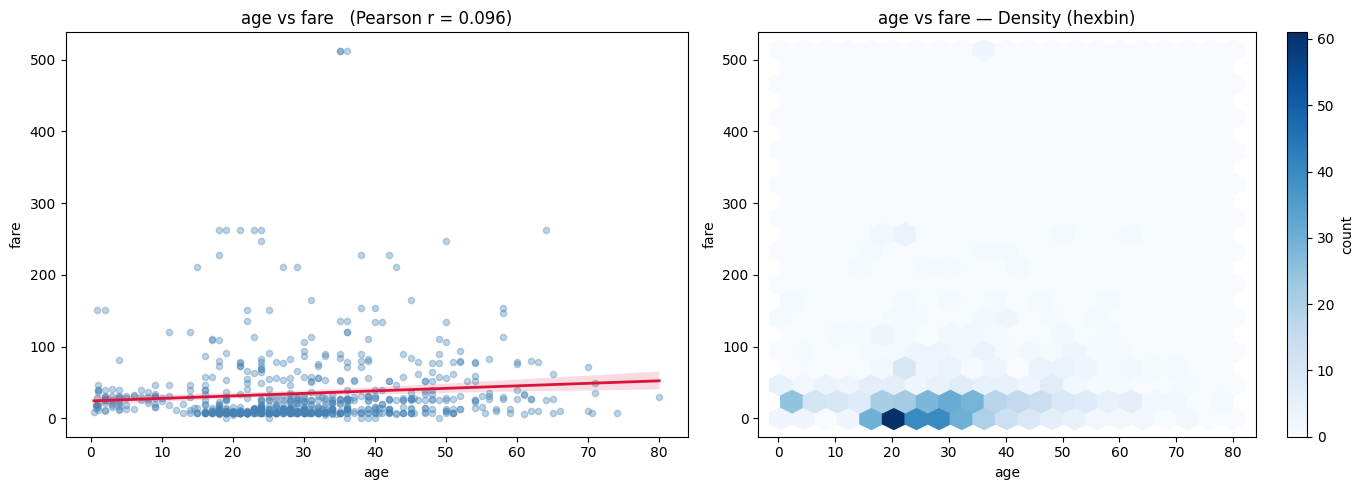

Pearson r = 0.0961   r² = 0.0092


In [2]:
def bivariate_num_num(df, x, y):
    """Scatter + hexbin density for two numerical variables."""
    df_sub = df[[x, y]].dropna()
    r = df_sub[x].corr(df_sub[y])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter with regression line
    sns.regplot(x=x, y=y, data=df_sub, ax=axes[0],
                scatter_kws={'alpha': 0.35, 's': 20, 'color': 'steelblue'},
                line_kws={'color': 'crimson', 'linewidth': 2})
    axes[0].set_title(f'{x} vs {y}   (Pearson r = {r:.3f})')

    # Hexbin density (better for large datasets)
    hb = axes[1].hexbin(df_sub[x], df_sub[y], gridsize=20, cmap='Blues')
    plt.colorbar(hb, ax=axes[1], label='count')
    axes[1].set_xlabel(x)
    axes[1].set_ylabel(y)
    axes[1].set_title(f'{x} vs {y} — Density (hexbin)')

    plt.tight_layout()
    plt.show()
    print(f"Pearson r = {r:.4f}   r\u00b2 = {r**2:.4f}")

bivariate_num_num(df, 'age', 'fare')

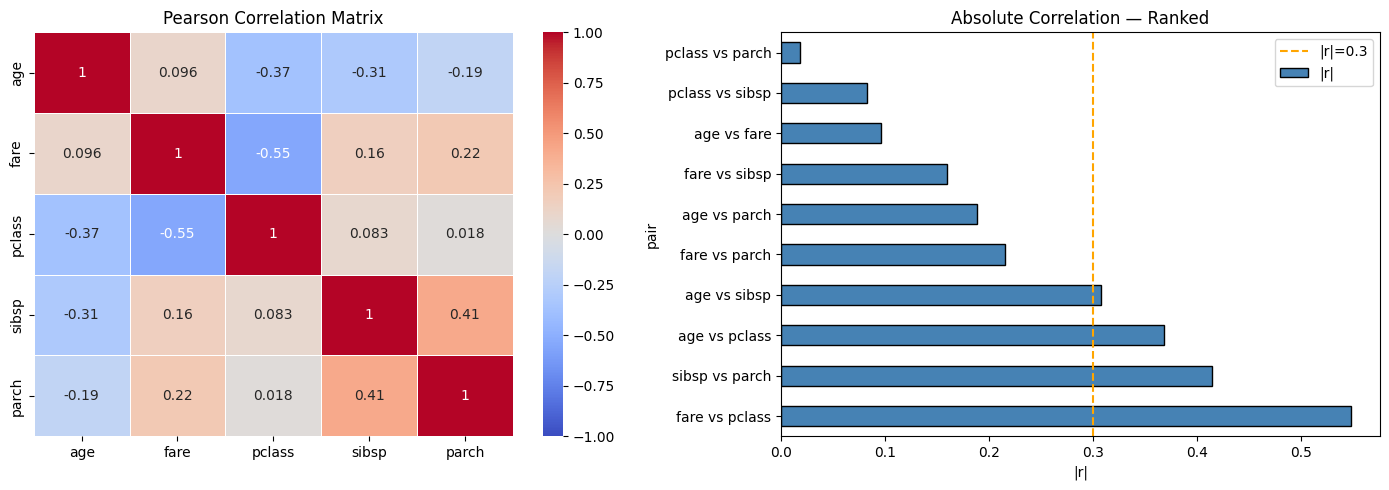

In [3]:
# Survey all numerical pairs
num_cols = ['age', 'fare', 'pclass', 'sibsp', 'parch']
corr_matrix = df[num_cols].corr().round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=axes[0], linewidths=0.5)
axes[0].set_title('Pearson Correlation Matrix')

# Highlight strongest pairs
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'r']
corr_pairs['|r|'] = corr_pairs['r'].abs()
corr_pairs = corr_pairs.sort_values('|r|', ascending=False)

corr_pairs['pair'] = corr_pairs['var1'] + ' vs ' + corr_pairs['var2']
corr_pairs.plot(x='pair', y='|r|', kind='barh', ax=axes[1],
                color='steelblue', edgecolor='black')
axes[1].set_title('Absolute Correlation — Ranked')
axes[1].set_xlabel('|r|')
axes[1].axvline(0.3, color='orange', linestyle='--', label='|r|=0.3')
axes[1].legend()

plt.tight_layout()
plt.show()

## Numerical vs Categorical

Compare how a numerical variable's distribution differs across the levels of a categorical variable. Useful for spotting which groups behave differently.

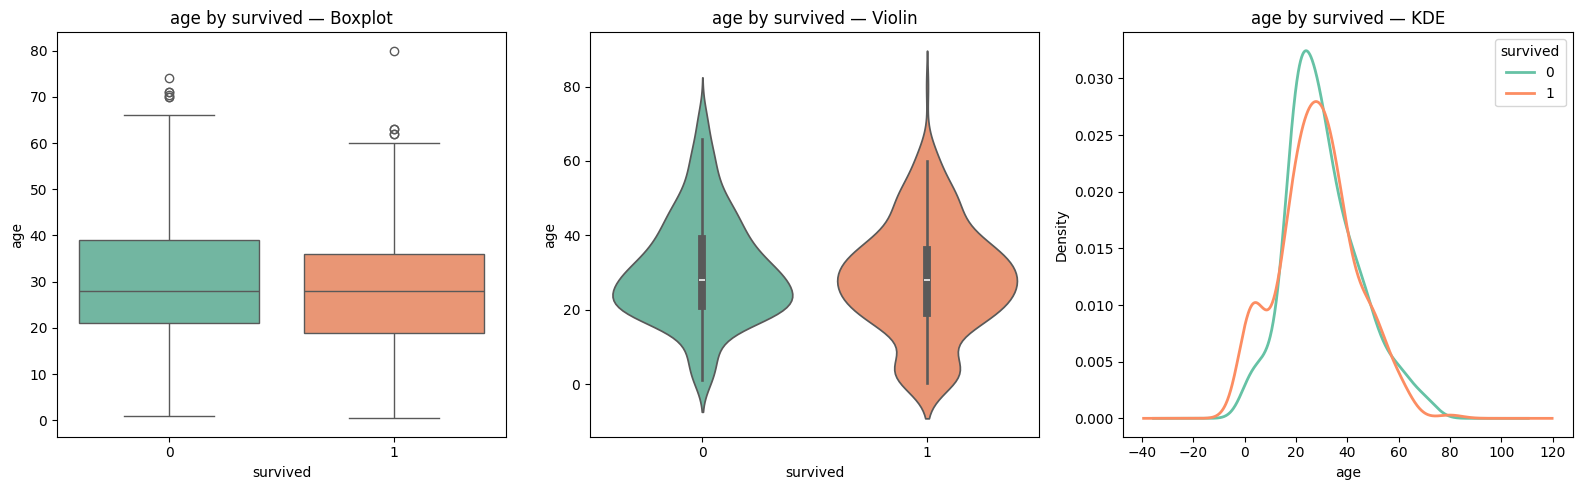

Group statistics:
          count   mean    std   min   25%   50%   75%   max
survived                                                   
0         424.0  30.63  14.17  1.00  21.0  28.0  39.0  74.0
1         290.0  28.34  14.95  0.42  19.0  28.0  36.0  80.0


In [4]:
def bivariate_num_cat(df, num_col, cat_col):
    """Boxplot, violin, and KDE overlay for a numerical vs categorical pair."""
    df_sub = df[[num_col, cat_col]].dropna()
    categories = sorted(df_sub[cat_col].unique())
    palette = sns.color_palette('Set2', len(categories))

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Boxplot
    sns.boxplot(x=cat_col, y=num_col, data=df_sub,
                order=categories, palette=palette, ax=axes[0])
    axes[0].set_title(f'{num_col} by {cat_col} — Boxplot')

    # Violin
    sns.violinplot(x=cat_col, y=num_col, data=df_sub,
                   order=categories, palette=palette, inner='box', ax=axes[1])
    axes[1].set_title(f'{num_col} by {cat_col} — Violin')

    # KDE overlay
    for cat_val, color in zip(categories, palette):
        subset = df_sub[df_sub[cat_col] == cat_val][num_col]
        subset.plot.kde(ax=axes[2], label=str(cat_val), color=color, linewidth=2)
    axes[2].set_title(f'{num_col} by {cat_col} — KDE')
    axes[2].legend(title=cat_col)
    axes[2].set_xlabel(num_col)

    plt.tight_layout()
    plt.show()

    print('Group statistics:')
    print(df_sub.groupby(cat_col)[num_col].describe().round(2).to_string())

bivariate_num_cat(df, 'age', 'survived')

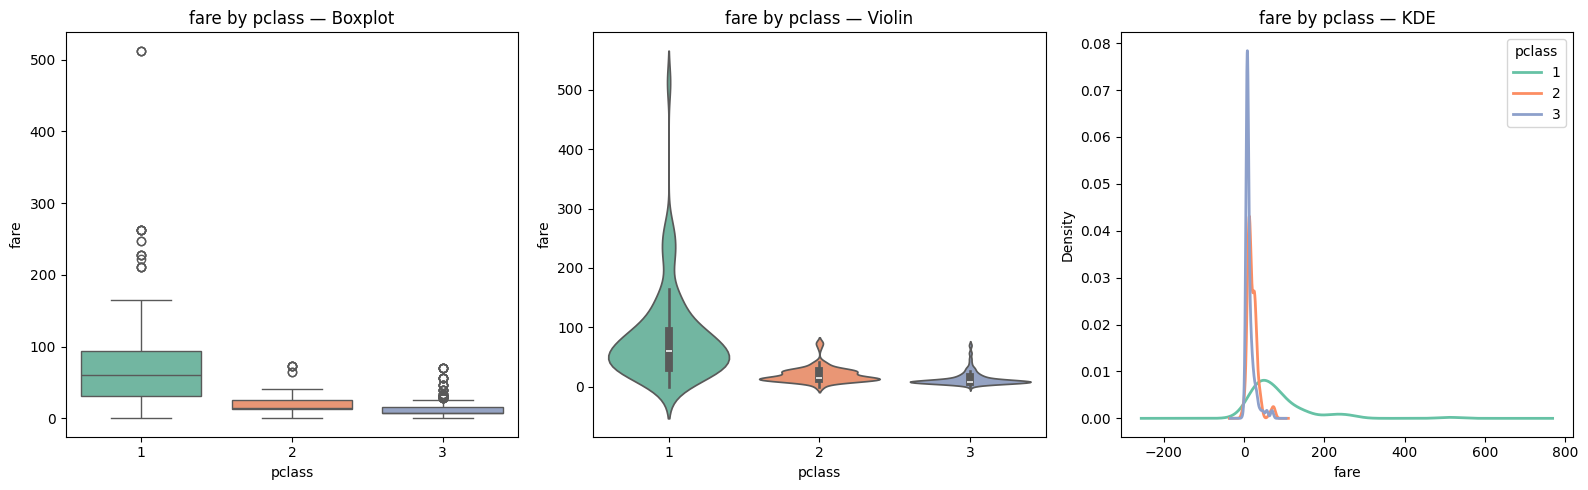

Group statistics:
        count   mean    std  min    25%    50%   75%     max
pclass                                                      
1       216.0  84.15  78.38  0.0  30.92  60.29  93.5  512.33
2       184.0  20.66  13.42  0.0  13.00  14.25  26.0   73.50
3       491.0  13.68  11.78  0.0   7.75   8.05  15.5   69.55


In [5]:
bivariate_num_cat(df, 'fare', 'pclass')

## Categorical vs Categorical

Use a cross-tabulation (contingency table) to count how often each combination of categories co-occurs. Visualise with a heatmap or stacked proportional bar chart.

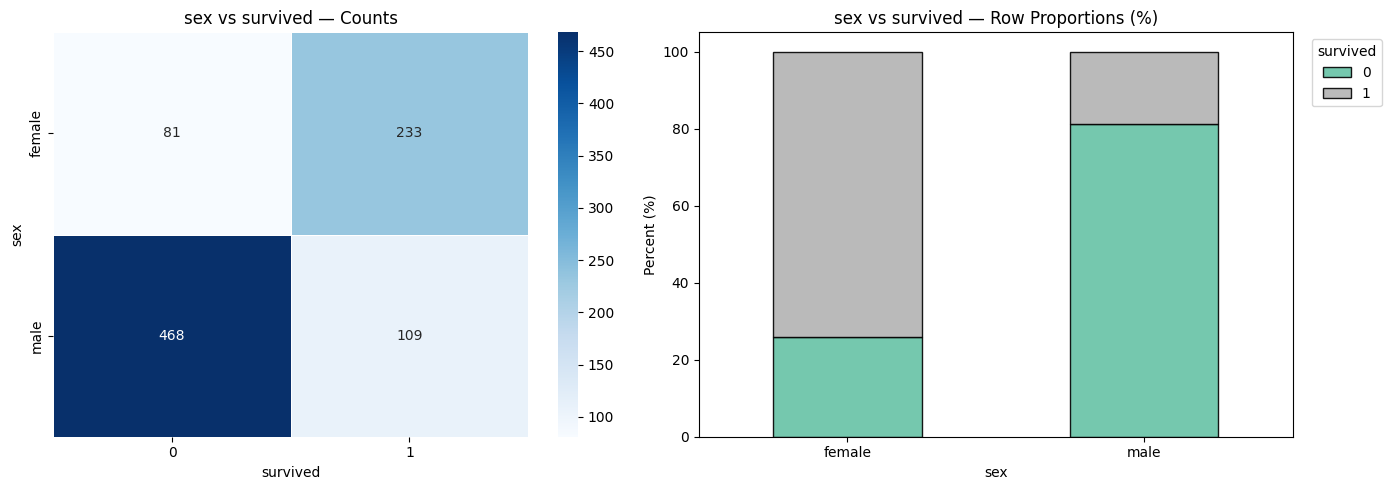

Count table:
survived    0    1
sex               
female     81  233
male      468  109

Row proportion (%) table:
survived     0     1
sex                 
female    25.8  74.2
male      81.1  18.9


In [6]:
def bivariate_cat_cat(df, col1, col2):
    """Crosstab heatmap and stacked proportion bar for two categorical variables."""
    ct_count = pd.crosstab(df[col1], df[col2])
    ct_pct   = pd.crosstab(df[col1], df[col2], normalize='index') * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Heatmap of raw counts
    sns.heatmap(ct_count, annot=True, fmt='d', cmap='Blues',
                linewidths=0.5, ax=axes[0])
    axes[0].set_title(f'{col1} vs {col2} — Counts')

    # Stacked bar of row proportions
    ct_pct.plot(kind='bar', stacked=True, ax=axes[1],
                colormap='Set2', edgecolor='black', alpha=0.9)
    axes[1].set_title(f'{col1} vs {col2} — Row Proportions (%)')
    axes[1].set_ylabel('Percent (%)')
    axes[1].legend(title=col2, bbox_to_anchor=(1.02, 1), loc='upper left')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

    print('Count table:')
    print(ct_count.to_string())
    print('\nRow proportion (%) table:')
    print(ct_pct.round(1).to_string())

bivariate_cat_cat(df, 'sex', 'survived')

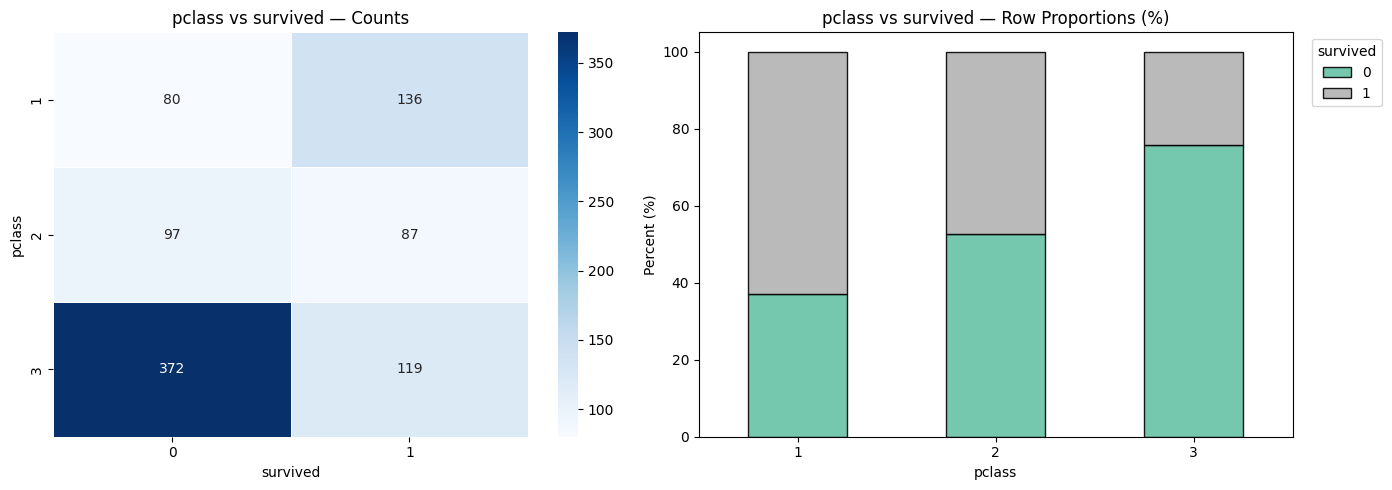

Count table:
survived    0    1
pclass            
1          80  136
2          97   87
3         372  119

Row proportion (%) table:
survived     0     1
pclass              
1         37.0  63.0
2         52.7  47.3
3         75.8  24.2


In [7]:
bivariate_cat_cat(df, 'pclass', 'survived')

## Systematic Bivariate Sweep vs Target

When preparing features for a model, systematically check every input variable against the target in one pass.

Numerical features vs target: survived

── age vs survived


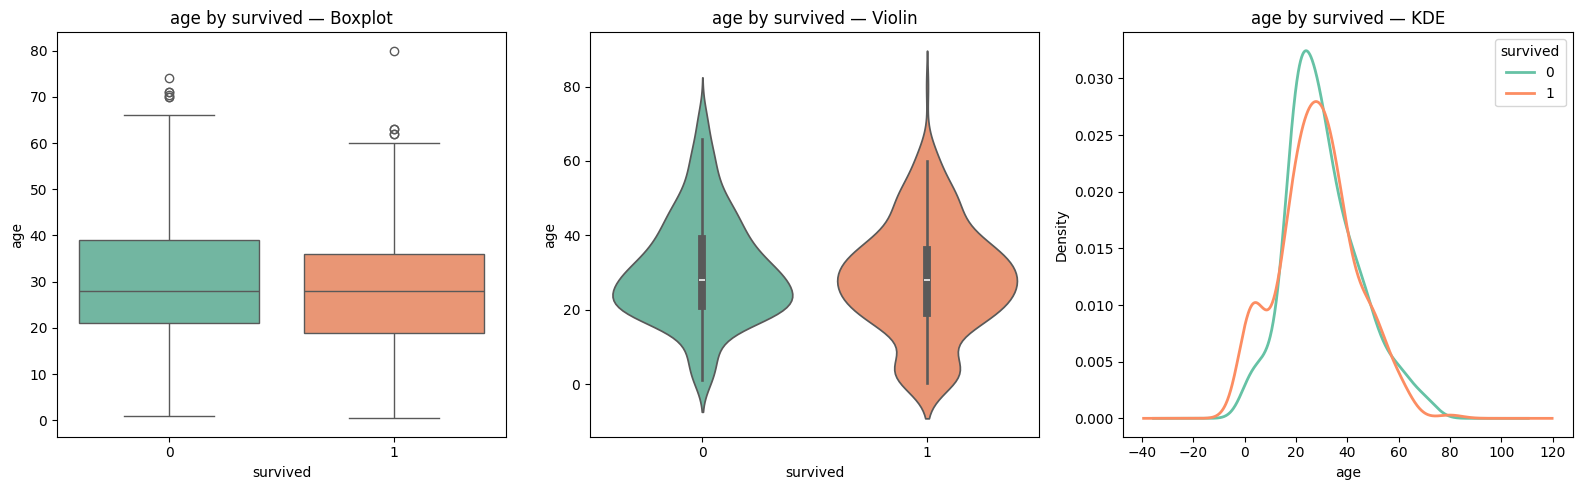

Group statistics:
          count   mean    std   min   25%   50%   75%   max
survived                                                   
0         424.0  30.63  14.17  1.00  21.0  28.0  39.0  74.0
1         290.0  28.34  14.95  0.42  19.0  28.0  36.0  80.0

── fare vs survived


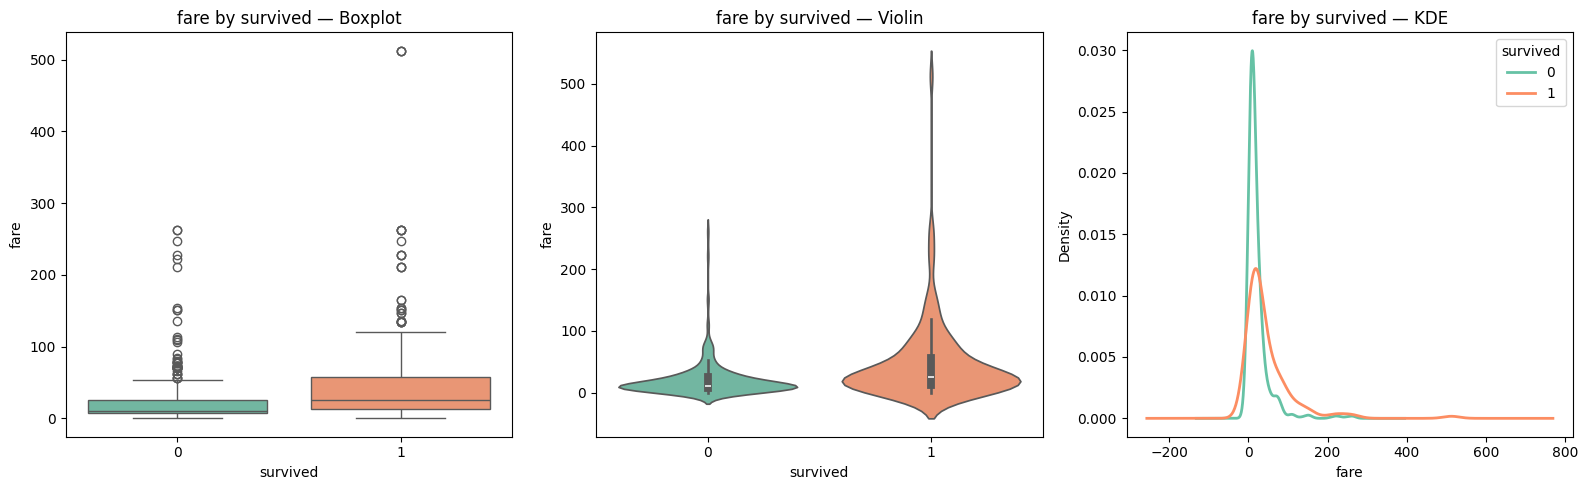

Group statistics:
          count   mean    std  min    25%   50%   75%     max
survived                                                     
0         549.0  22.12  31.39  0.0   7.85  10.5  26.0  263.00
1         342.0  48.40  66.60  0.0  12.48  26.0  57.0  512.33
Categorical features vs target: survived

── sex vs survived


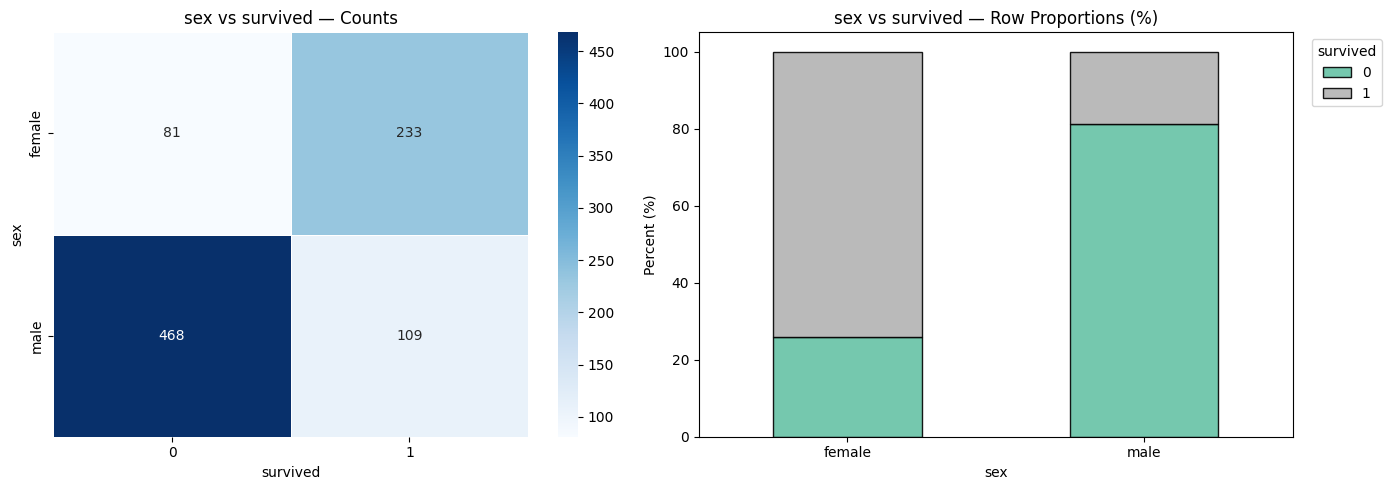

Count table:
survived    0    1
sex               
female     81  233
male      468  109

Row proportion (%) table:
survived     0     1
sex                 
female    25.8  74.2
male      81.1  18.9

── pclass vs survived


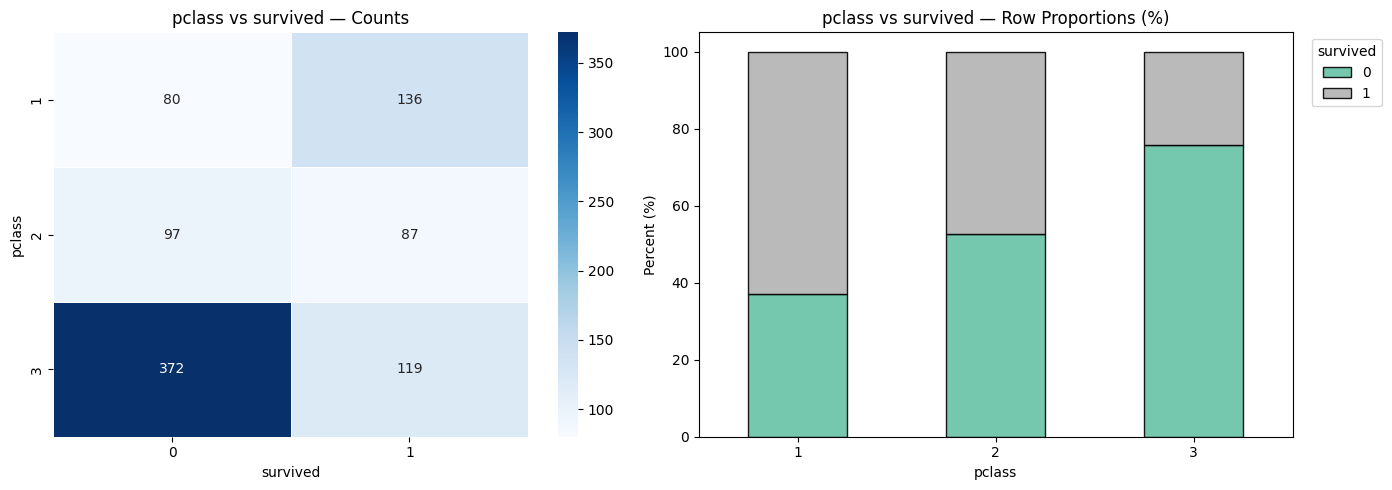

Count table:
survived    0    1
pclass            
1          80  136
2          97   87
3         372  119

Row proportion (%) table:
survived     0     1
pclass              
1         37.0  63.0
2         52.7  47.3
3         75.8  24.2


In [8]:
def bivariate_sweep_vs_target(df, target, num_cols=None, cat_cols=None):
    """Profile every feature against the target variable."""
    num_cols = num_cols or [
        c for c in df.select_dtypes(include=['int64', 'float64']).columns
        if c != target
    ]
    cat_cols = cat_cols or [
        c for c in df.select_dtypes(include=['object', 'category', 'bool']).columns
        if c != target
    ]

    target_is_cat = df[target].nunique() <= 10

    print('=' * 60)
    print(f'Numerical features vs target: {target}')
    print('=' * 60)
    for col in num_cols:
        print(f'\n── {col} vs {target}')
        if target_is_cat:
            bivariate_num_cat(df, col, target)
        else:
            bivariate_num_num(df, col, target)

    print('=' * 60)
    print(f'Categorical features vs target: {target}')
    print('=' * 60)
    for col in cat_cols:
        print(f'\n── {col} vs {target}')
        bivariate_cat_cat(df, col, target)

# Demo: two features vs survived
bivariate_sweep_vs_target(
    df, target='survived',
    num_cols=['age', 'fare'],
    cat_cols=['sex', 'pclass']
)

## Key Takeaways

| Pair type | Best plots | Key metric | Statistical test |
|---|---|---|---|
| Numerical vs Numerical | Scatter + regression line, hexbin | Pearson r | — |
| Numerical vs Categorical | Boxplot, violin, KDE overlay | Group means / medians | t-test / Mann-Whitney U |
| Categorical vs Categorical | Crosstab heatmap, stacked bar | Row proportions | Chi-square + Cramér's V |

**What bivariate EDA tells you before modelling:**
- Which features are linearly correlated with each other (potential multicollinearity)
- Which features separate the target classes most clearly
- Which categorical combinations are rare (sparse cells in crosstab)

**Statistical tests complement visuals:**
- Visuals show the *shape* and *direction* of a relationship
- p-values confirm whether the relationship is real or could be sampling noise
- Effect sizes (Pearson r, Cohen's d, Cramér's V) measure the *strength* independently of sample size

---
## Statistical Tests for Bivariate Relationships

Visualisations reveal *what* the data looks like — statistical tests quantify *how confident* we can be that the pattern is real and not due to chance.

| Comparison | Visual | Statistical test |
|---|---|---|
| Numerical vs Categorical (2 groups) | Boxplot, violin | **Two-sample t-test** or **Mann-Whitney U** |
| Categorical vs Categorical | Crosstab heatmap | **Chi-square test of independence** |

### Two-Sample t-Test and Mann-Whitney U

**Question**: Does the mean (or distribution) of a numerical variable differ significantly between two groups?

**Two-sample t-test**: assumes the two groups are normally distributed with similar variance.
**Mann-Whitney U**: non-parametric alternative — no normality assumption; compares rank distributions.

- H₀ (null): the two groups have the same mean / distribution
- p < 0.05 → reject H₀ → difference is statistically significant

**Effect size (Cohen's d)**: measures *practical* significance, not just statistical.

| |d| | Interpretation |
|---|---|
| 0.2 | Small effect |
| 0.5 | Medium effect |
| 0.8 | Large effect |

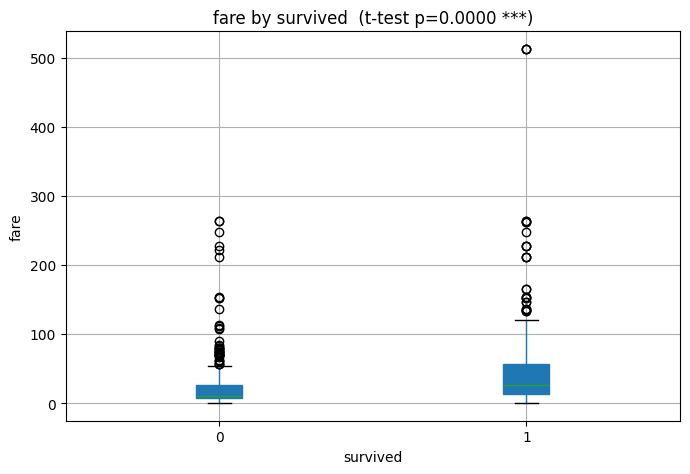


  fare  by  survived
  Group '0':  n=549, mean=22.118, std=31.388
  Group '1':  n=342, mean=48.395, std=66.597

  Two-sample t-test:   t=-6.839,  p=0.0000  ← significant
  Mann-Whitney U test: U=57806,  p=0.0000  ← significant
  Cohen's d:           -0.505  (medium effect)


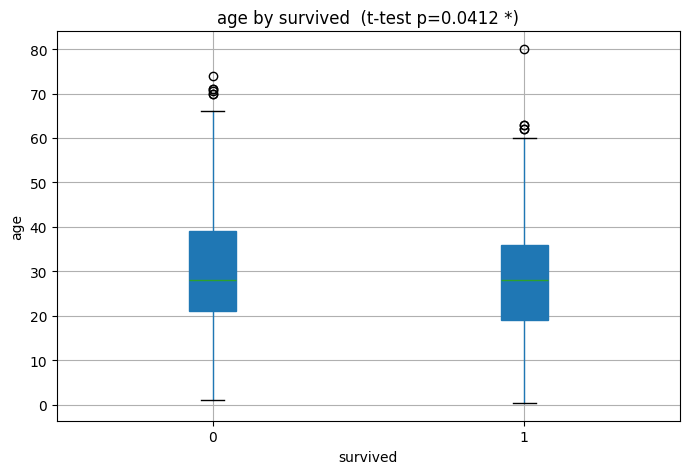


  age  by  survived
  Group '0':  n=424, mean=30.626, std=14.172
  Group '1':  n=290, mean=28.344, std=14.951

  Two-sample t-test:   t=2.046,  p=0.0412  ← significant
  Mann-Whitney U test: U=65278,  p=0.1605  
  Cohen's d:           0.157  (small effect)


In [9]:
from scipy import stats

def test_num_vs_binary_cat(df, num_col, cat_col):
    """
    Two-sample t-test + Mann-Whitney U for a numerical column vs a binary categorical.
    Prints results and shows a boxplot with significance annotation.
    """
    cats = df[cat_col].dropna().unique()
    if len(cats) != 2:
        print(f"  {cat_col} has {len(cats)} categories — need exactly 2 for this test")
        return

    g1 = df[df[cat_col] == cats[0]][num_col].dropna()
    g2 = df[df[cat_col] == cats[1]][num_col].dropna()

    # Two-sample t-test
    t_stat, p_ttest = stats.ttest_ind(g1, g2, equal_var=False)

    # Mann-Whitney U (non-parametric)
    u_stat, p_mwu = stats.mannwhitneyu(g1, g2, alternative='two-sided')

    # Cohen's d
    pooled_std = np.sqrt((g1.std()**2 + g2.std()**2) / 2)
    cohens_d = (g1.mean() - g2.mean()) / pooled_std if pooled_std > 0 else 0

    # Visual
    fig, ax = plt.subplots(figsize=(7, 5))
    df[[num_col, cat_col]].dropna().boxplot(by=cat_col, column=num_col, ax=ax,
                                             patch_artist=True)
    ax.set_title(f'{num_col} by {cat_col}')
    ax.set_xlabel(cat_col)
    ax.set_ylabel(num_col)

    sig = '***' if p_ttest < 0.001 else ('**' if p_ttest < 0.01 else ('*' if p_ttest < 0.05 else 'ns'))
    ax.set_title(f'{num_col} by {cat_col}  (t-test p={p_ttest:.4f} {sig})')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()

    print(f"\n  {num_col}  by  {cat_col}")
    print(f"  Group '{cats[0]}':  n={len(g1)}, mean={g1.mean():.3f}, std={g1.std():.3f}")
    print(f"  Group '{cats[1]}':  n={len(g2)}, mean={g2.mean():.3f}, std={g2.std():.3f}")
    print()
    print(f"  Two-sample t-test:   t={t_stat:.3f},  p={p_ttest:.4f}  {'← significant' if p_ttest < 0.05 else ''}")
    print(f"  Mann-Whitney U test: U={u_stat:.0f},  p={p_mwu:.4f}  {'← significant' if p_mwu < 0.05 else ''}")
    print(f"  Cohen's d:           {cohens_d:.3f}  ({'large' if abs(cohens_d) >= 0.8 else 'medium' if abs(cohens_d) >= 0.5 else 'small'} effect)")


test_num_vs_binary_cat(df, 'fare', 'survived')
test_num_vs_binary_cat(df, 'age', 'survived')

### Chi-Square Test of Independence

**Question**: Are two categorical variables associated, or are they independent?

- H₀: the two variables are independent (no association)
- p < 0.05 → reject H₀ → the variables are associated

**Cramér's V**: effect size for categorical association, ranges from 0 (no association) to 1 (perfect association). Adjusted for table size so it's comparable across different crosstab dimensions.

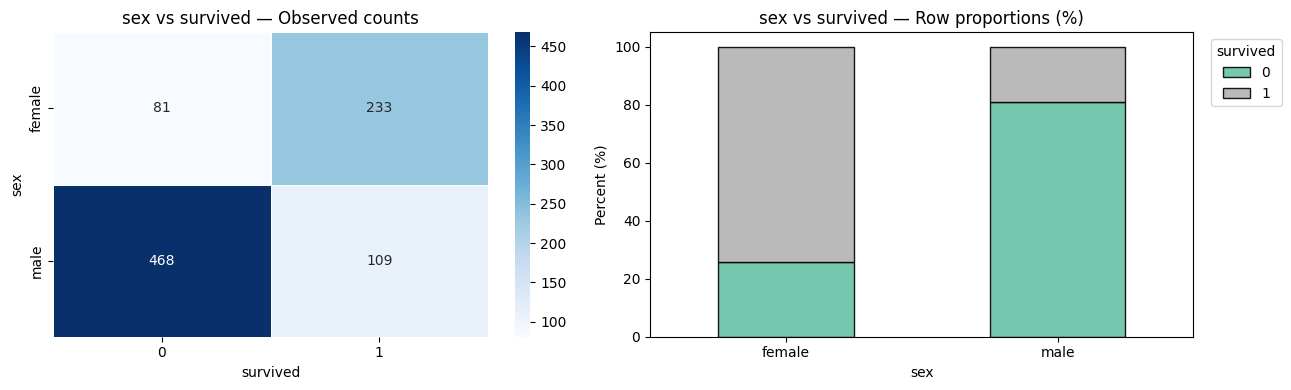


  Chi-square test — sex vs survived
  χ² = 260.717,  df = 1,  p = 0.0000  ***
  Cramér's V = 0.541  (strong association)
  Variables are associated (reject H₀)


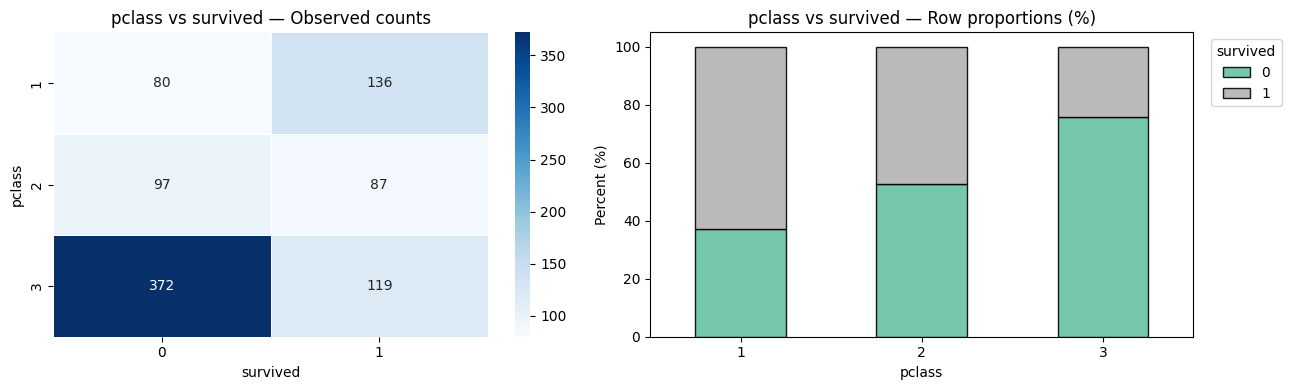


  Chi-square test — pclass vs survived
  χ² = 102.889,  df = 2,  p = 0.0000  ***
  Cramér's V = 0.340  (moderate association)
  Variables are associated (reject H₀)


In [10]:
def test_cat_vs_cat(df, col1, col2):
    """
    Chi-square test of independence + Cramér's V for two categorical variables.
    """
    ct = pd.crosstab(df[col1], df[col2])

    chi2, p, dof, expected = stats.chi2_contingency(ct)

    n = ct.values.sum()
    min_dim = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

    # Visual: side-by-side heatmap and row proportions
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=axes[0])
    axes[0].set_title(f'{col1} vs {col2} — Observed counts')

    ct_pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(1)
    ct_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2', edgecolor='black', alpha=0.9)
    axes[1].set_title(f'{col1} vs {col2} — Row proportions (%)')
    axes[1].set_ylabel('Percent (%)')
    axes[1].legend(title=col2, bbox_to_anchor=(1.02, 1), loc='upper left')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

    strength = 'strong' if cramers_v >= 0.5 else ('moderate' if cramers_v >= 0.3 else 'weak')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))

    print(f"\n  Chi-square test — {col1} vs {col2}")
    print(f"  χ² = {chi2:.3f},  df = {dof},  p = {p:.4f}  {sig}")
    print(f"  Cramér's V = {cramers_v:.3f}  ({strength} association)")
    print(f"  {'Variables are associated (reject H₀)' if p < 0.05 else 'No significant association (fail to reject H₀)'}")


test_cat_vs_cat(df, 'sex', 'survived')
test_cat_vs_cat(df, 'pclass', 'survived')